# Lake Poopó essential climate variables 

In this notebook, I extract 3 essential climate variables (ECV) for Lake Poopó from the Lakes_cci version 2.1 project dataset produced under the ESA Climate Change Initiative (CCI). This is a dataset derived from satellite observations using a variety of remote sensing techniques, more detaild can be found [here](https://climate.esa.int/en/projects/lakes/).


In [1]:
from pathlib import Path
import numpy as np
import xarray as xr
import datetime
import pandas as pd
import urllib.request
import matplotlib.pyplot as plt
import os
import matplotlib.dates as mdates
from src.lakeclimate import cci


path_root = Path.cwd()

path_to_cci = path_root / "data_cci"
path_to_jrc = path_root / "data_jrc"
path_to_cds = path_root / "data_cds"

## 1. Extract data from lakes_cci


Before extracting the ECVs, we download the lake metadata .csv file (including their location, identifier and essential climate variables (ECV) availability) and the netCDF file containing the mask of the lake. This has to be run only once.

In [ ]:

lakes_metadata_url = "https://climate.esa.int/media/documents/lakescci_v2.1_metadata.csv"
metadata_path = path_root / "data_cci" / "lakes_v2.1_metadata.csv"
urllib.request.urlretrieve(lakes_metadata_url, metadata_path)
print("Metadata CSV file downloaded successfully.")

lake_mask_url = "https://raw.github.com/cci-lakes/lakes_cci_tools/main/ESA_CCI_static_lake_mask_v2.1.nc"
lake_mask_path = path_to_cci / "raw"/ "ESA_CCI_static_lake_mask_v2.1.nc"
urllib.request.urlretrieve(lake_mask_url, lake_mask_path)
print("Static lake mask NetCDF file downloaded successfully.")


Metadata CSV file downloaded successfully.
Static lake mask NetCDF file downloaded successfully.


Next step is to define the input parameters. Based on the Lakes_cci metadata, Lake Poopó' is designated with lake_id = 133.

In [2]:
maskfile = path_to_cci / "raw"/ "ESA_CCI_static_lake_mask_v2.1.nc"
lake_id = 133
version = '2.1'
# defining the period of time in string format: YYYY-MM-DD
# dates values must be between 1992-09-26 and 2020-12-31
mindate = '2000-01-01'
maxdate = '2000-04-30'


To isolate the data in the region covering the lake, we use the lake mask file to retrieve both latitude and longitude values inside the lake.

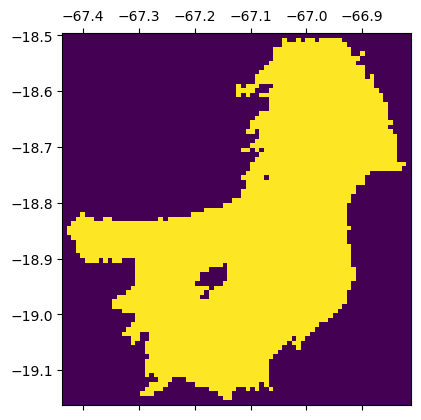

In [3]:

mask_lake, miny, maxy, minx, maxx = cci.build_lake_mask(maskfile, lake_id)
mask_xr = xr.open_dataset(maskfile)
lat = mask_xr['lat'][miny:maxy+1].values
lon = mask_xr['lon'][minx:maxx+1].values
plt.matshow(mask_lake, extent=[np.min(lon), np.max(lon), np.min(lat), np.max(lat)])
plt.show()

We extract the following 3 ECVs:

LWL : 'water_surface_height_above_reference_datum' <br>
LWE : 'lake_surface_water_extent'  <br>
LSWT : 'lake_surface_water_temperature'  <br>

Below, we show an example of how to extract daily LWL data.

In [4]:

varname = 'water_surface_height_above_reference_datum' 
df, units = cci.extract_variable_timeseries(lake_id, varname, (mindate,maxdate), maskfile, version)

We construct a dataframe and plot the lake variable:

        date  water_surface_height_above_reference_datum
0 2000-02-17                                 3686.050049
1 2000-02-24                                 3687.030029
2 2000-03-14                                 3687.080322
3 2000-03-21                                 3687.019775
4 2000-04-01                                 3687.000000
5 2000-04-08                                 3686.949951
6 2000-04-16                                 3686.919678
7 2000-04-23                                 3686.859863
8 2000-04-30                                 3686.859863


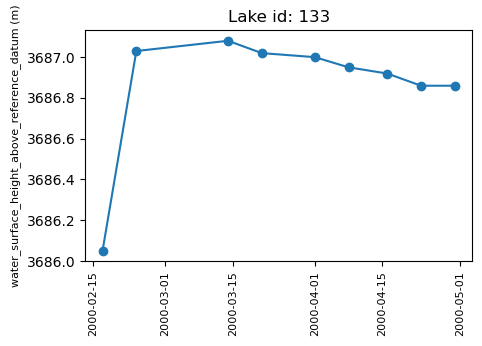

In [5]:
df['date'] = pd.to_datetime(df['date'], format = '%Y%m%d')
print(df)

if units == '1' :
    units = 'no units'

fig, ax = plt.subplots(figsize=(5,3))
ax.plot(df['date'], df[varname], marker='o', linestyle="-")
ax.set_title(f'Lake id: {lake_id}')
plt.ylabel(f'{varname} ({units})', fontsize=8)
plt.xticks(rotation=90, fontsize =8)
df[varname] = np.round(df[varname], 3)
plt.show()

We can already see that the LWL data is quite sparse, with some months having only 2 data points.

# Visualization of ECVs 



Since data extraction takes time, I pre-downloaded the available datasets for the following 3 ECVs:

## Water surface height (LWL) 

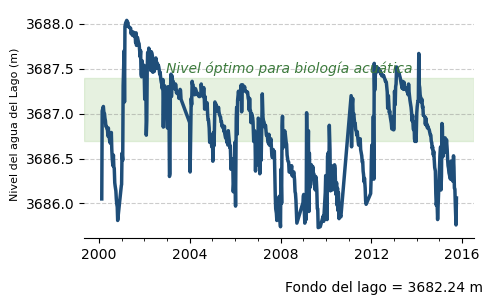

In [6]:

varname ='water_surface_height_above_reference_datum' 
lake_bed = 3682.24                    # dry lake floor
eco_low, eco_high = 3686.7, 3687.4    # optimal ecological band

lwl_path = path_to_cci / "processed" / "Poopo_lwl_2000-2015.csv"
lwl_df = pd.read_csv(lwl_path)
lwl_df["date"] = pd.to_datetime(lwl_df["date"])

fig, ax = plt.subplots(figsize=(5,3))
ax.plot(lwl_df['date'], lwl_df[varname],  linestyle="-", linewidth =2.5,  color="#1f4e79")
ax.xaxis.set_major_locator(mdates.YearLocator(base=4)) 
ax.xaxis.set_minor_locator(mdates.YearLocator(base=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_ylabel(f'Nivel del agua del Lago (m)', fontsize=8)
ax.grid(
    axis='y',
    linestyle='--',     
    linewidth=0.8,
    color='gray',
    alpha=0.4
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_alpha(0)
ax.spines['bottom'].set_alpha(1)
ax.tick_params(axis='both', labelsize=10)

# Optimal ecological range
ax.axhspan(eco_low, eco_high, color="#9CCB86", alpha=0.25, zorder=0)
ax.text(lwl_df["date"].iloc[120], eco_high+0.18,
        "Nivel óptimo para biología acuática",
        fontsize=10, color="#3C7A3C", style="italic", va="top")

plt.figtext(0.58, 0.01, f"Fondo del lago = {lake_bed} m", wrap=True, horizontalalignment='left', fontsize=10)
plt.tight_layout()
plt.subplots_adjust(bottom=0.19) 
path_to_save = path_root / "figures" / "Poopo_lwl_2000-2015.png"
plt.savefig(path_to_save, transparent = True)


# Lake Water Extent (LWE)

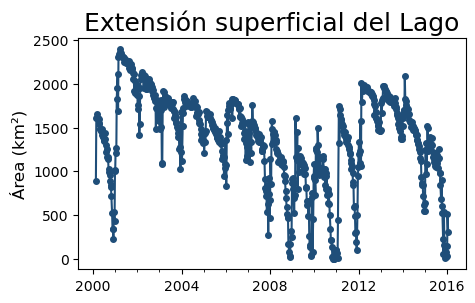

In [ ]:
lwe_path = path_to_cci / "processed" / "Poopo_lwe_2000-2016.csv"
lwe_df = pd.read_csv(lwe_path)
lwe_df["date"] = pd.to_datetime(lwe_df["date"])

fig, ax = plt.subplots(figsize=(5,3))
ax.plot(lwe_df['date'], lwe_df['lake_surface_water_extent'], marker='o',markersize = 4, linestyle="-", color="#1f4e79")
ax.xaxis.set_major_locator(mdates.YearLocator(base=4))
ax.xaxis.set_minor_locator(mdates.YearLocator(base=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.set_title(f'Extensión superficial del Lago', fontsize= 18)
ax.set_ylabel(f'Área (km²)', fontsize=12)
path_to_save = path_root / "figures" / "Poopo_lwe_2000-2016.png"
plt.savefig(path_to_save, transparent = True)


# Lake surface water temperature (LSWT)

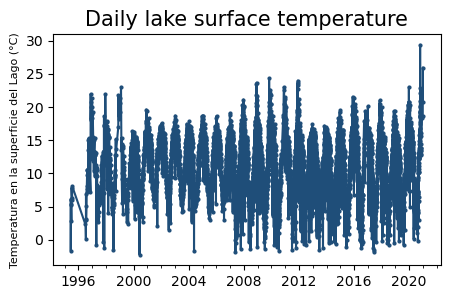

In [7]:
varname = "lake_surface_water_temperature"
lswt_path = path_to_cci / "processed" / "Poopo_lswt_1995-2020.csv"
lswt_df = pd.read_csv(lswt_path)
lswt_df["date"] = pd.to_datetime(lswt_df["date"])

fig, ax = plt.subplots(figsize=(5,3))

ax.plot(lswt_df['date'], lswt_df[varname]- 273.15, marker='o',markersize = 2, linestyle="-", color="#1f4e79")
ax.xaxis.set_major_locator(mdates.YearLocator(base=4))
ax.xaxis.set_minor_locator(mdates.YearLocator(base=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.set_title(f'Daily lake surface temperature', fontsize= 15)
ax.set_ylabel(f'Temperatura en la superficie del Lago (°C)', fontsize=8)
path_to_save = path_root / "figures" / "Poopo_lswt_1995-2020.png"
plt.savefig(path_to_save, transparent = True)


Transforming lswt data into monthly and annual mean temperature data.

In [8]:

monthly_df = cci.daily_to_monthly(lswt_df, varname, min_obs_per_month=3)
# Convert to Celsius
monthly_df[varname] = monthly_df[varname] - 273.15
monthly_df = monthly_df.rename(columns={varname: "t_C"})
print("Monthly data: \n")
print(monthly_df.head())
annual_df = cci.monthly_to_annual(monthly_df,"t_C",min_obs_per_year=11)
print("Annual data: \n")
print(annual_df.head())

Monthly data: 

   year  month        t_C
0  1995      6   3.991167
1  1995      7   7.056750
2  1996      7   3.416833
3  1996      8   8.955167
4  1996      9  12.382429
Annual data: 

   year        t_C
0  1997  10.522620
1  1998  12.233052
2  1999  11.087977
3  2000  11.362064
4  2001  12.240257


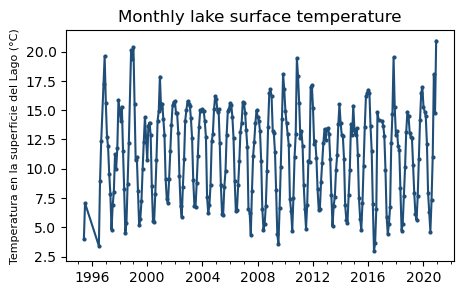

In [9]:

fig, ax = plt.subplots(figsize=(5,3))

monthly_df['date'] = pd.to_datetime(dict(year=monthly_df['year'], month=monthly_df['month'], day=1))
ax.plot(monthly_df['date'], monthly_df["t_C"], marker='o',markersize = 2, linestyle="-", color="#1f4e79")
ax.xaxis.set_major_locator(mdates.YearLocator(base=4))
ax.xaxis.set_minor_locator(mdates.YearLocator(base=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.set_title(f'Monthly lake surface temperature', fontsize= 12)
ax.set_ylabel(f'Temperatura en la superficie del Lago (°C)', fontsize=8)

plt.show()

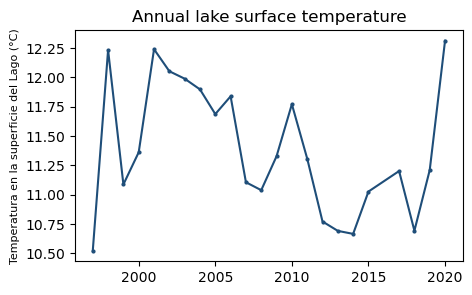

In [10]:
fig, ax = plt.subplots(figsize=(5,3))

ax.plot(annual_df['year'], annual_df["t_C"], marker='o',markersize = 2, linestyle="-", color="#1f4e79")
ax.set_title(f'Annual lake surface temperature', fontsize= 12)
ax.set_ylabel(f'Temperatura en la superficie del Lago (°C)', fontsize=8)

plt.show()

Unfortunately, the daily lake surface temperature data is highly sparse, resulting in a significant  amount of noise in the annual trend.